# White light CCF of HD 189733 - two nights

In this notebook, we present a simple example of the application of the Doppler Shadow technique to two nights of ESPRESSO observations of HD 189733, a K1V star, extracting the white light CCFs provided by the DRS. The nights of observations were 11-08-2021 and 31-08-2021.

We run two different instances of HECATE and then use the multi_night_analysis class to combine the data.

In [1]:
import numpy as np

from HECATE.HECATE import HECATE   # main class
from HECATE.get_data import *
from HECATE.multi_dataset_analysis import multi_dataset_analysis # to perform the multi-night analysis

Warming up JIT-compiled functions...


In [2]:
stellar_params = {
                "Teff":4969, "Teff_err":43,   #effective temperature [K]
                "logg":4.60, "logg_err":0.01, #superficial gravity [dex]
                "FeH":-0.07, "FeH_err":0.02,  #metallicity [dex]
                "P_rot":2.21857312,           #rotation period [d]
                "R_star":0.766,               #radius [solar radii]
                "inc_star":71.87              #stellar inclination [º]
                }

planet_params = {
                "P_orb":2.21857312,           #orbital period [d]
                "a_R":8.76863,                #system scale [stellar radii]
                "Rp_Rs":0.1602,               #planet-to-star radius ratio 
                "t0":53988.30339,             #mid-transit time [d]
                "e":0,                        #orbital eccentricity
                "w":90,                       #argument of periastron [º]
                "inc_planet":85.465,          #planet inclination [º]
                "lbda":-1.00,                 #spin-orbit angle [º]
                "dfp": -0.002424              #mid-transit phase shift, night of 2021-09-11
                }

Now we quickly run HECATE for the first night of observations, saving the local CCF parameters.

In [3]:
CCFs, time, airmass, berv, bervmax, snr, list_ccfs = get_CCFs(planet_params, stellar_params,
                                                              day='2021-08-11', 
                                                              directory_path="HD189733_ESPRESSO_white_light_ccfs",
                                                              plot=False)

In [4]:
hecate11 = HECATE(planet_params, stellar_params, time, CCFs, spectra=None, plot_soap=False)

In [5]:
plot = {"fits_initial_CCF":False,         # plot the initial fits to the CCFs
        "sys_vel_ccf":False,              # plot the systemic velocity of the star in the CCFs
        "master_out_of_transit":False,    # plot the master out-of-transit CCF
        "local_CCFs":True,                # plot the local CCFs
        "photometrical_rescale":False     # if the local CCFs are rescaled by the photometric transit model
        }

ccf_type = "white light"
model_fit = "modified Gaussian"

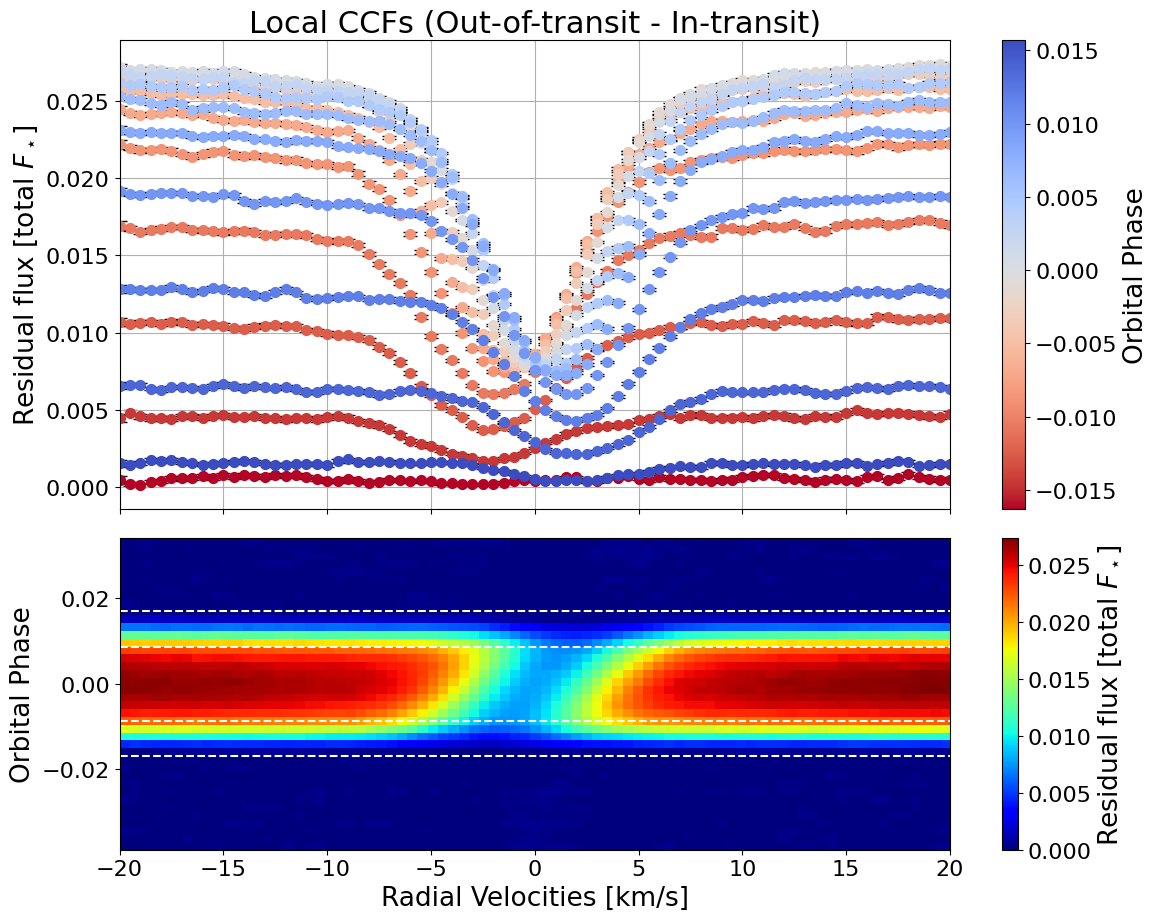

In [6]:
local_data11 = hecate11.extract_local_CCF(model_fit, plot, save=None)

In [7]:
master_results11 = hecate11.get_profile_parameters(profiles=local_data11['master_out_of_transit_CCF'], 
                                               data_type="CCF", 
                                               observation_type="master", 
                                               model="modified Gaussian", 
                                               print_output=False, 
                                               plot_fit=False)

In [8]:
local_results11 = hecate11.get_profile_parameters(profiles=local_data11['local_CCFs'], 
                                              data_type="CCF", 
                                              observation_type="local", 
                                              model="modified Gaussian", 
                                              print_output=False, 
                                              plot_fit=False)

In [9]:
indices_final11 = np.array(list(set(np.where(local_results11['R2'] >= 0.95)[0]).intersection(set(np.where(hecate11.mu_in >= 0.3)[0]))))

local_params11 = [local_results11['central_rv'], local_results11['width'], local_results11['intensity']]
master_params11 = [master_results11['central_rv'], master_results11['width'], master_results11['intensity']]

Now we do the same for the second night.

In [10]:
planet_params["dfp"] = -0.002300    # mid-transit phase shift, night of 2021-08-31

In [11]:
CCFs, time, airmass, berv, bervmax, snr, list_ccfs = get_CCFs(planet_params, stellar_params,
                                                              day='2021-08-31', 
                                                              directory_path="HD189733_ESPRESSO_white_light_ccfs",
                                                              plot=False)

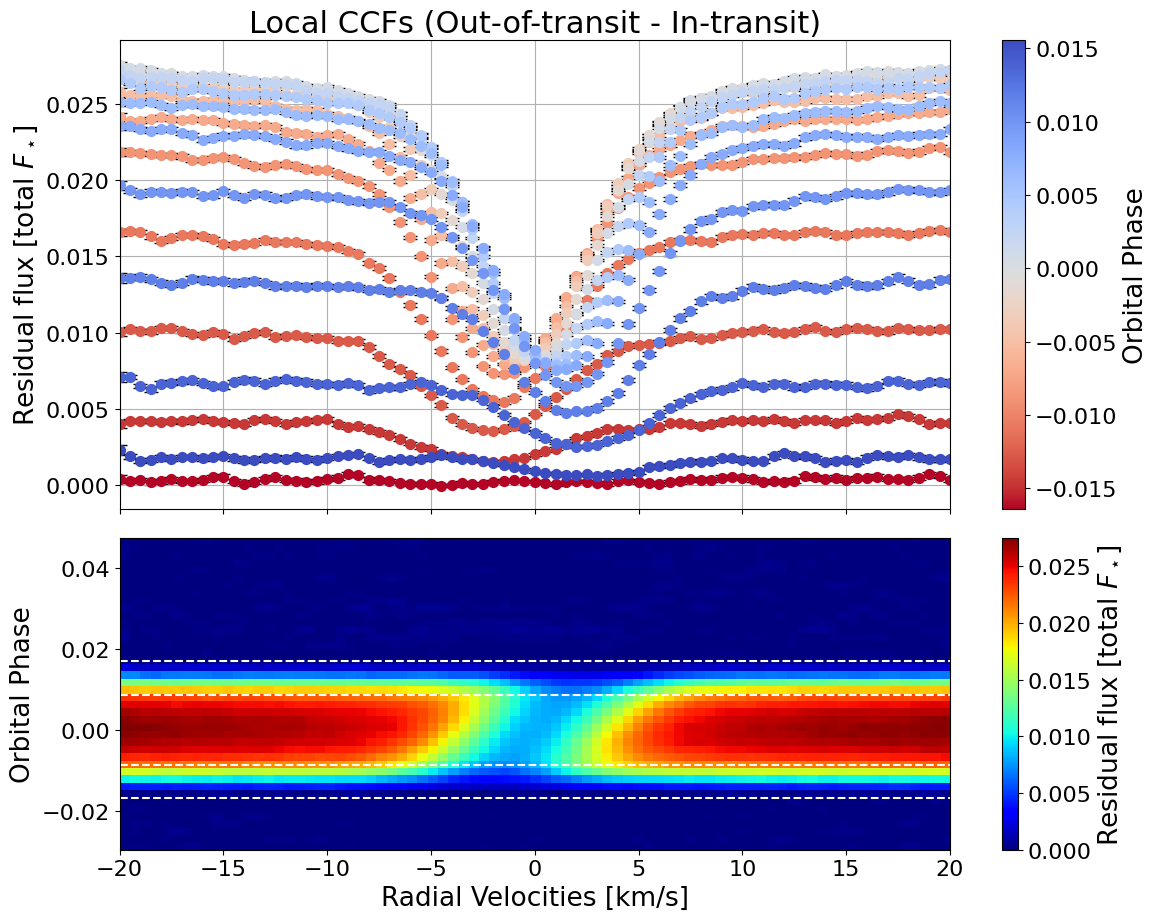

In [12]:
hecate31 = HECATE(planet_params, stellar_params, time, CCFs, None)

plot = {"fits_initial_CCF":False, 
        "sys_vel_ccf":False, 
        "master_out_of_transit":False, 
        "local_CCFs":True, 
        "photometrical_rescale":False}

ccf_type = "white light"
model_fit = "modified Gaussian"

local_data31 = hecate31.extract_local_CCF(model_fit, plot, save=None)

In [13]:
master_results31 = hecate31.get_profile_parameters(profiles=local_data31['master_out_of_transit_CCF'], data_type="CCF", 
                                                    observation_type="master", model="modified Gaussian", 
                                                    print_output=False, plot_fit=False)

local_results31 = hecate31.get_profile_parameters(profiles=local_data31['local_CCFs'], data_type="CCF", 
                                                    observation_type="local", model="modified Gaussian", 
                                                    print_output=False, plot_fit=False)

In [14]:
indices_final31 = np.array(list(set(np.where(local_results31['R2'] >= 0.9)[0]).intersection(set(np.where(hecate31.mu_in >= 0.3)[0]))))

local_params31 = [local_results31['central_rv'], local_results31['width'], local_results31['intensity']]
master_params31 = [master_results31['central_rv'], master_results31['width'], master_results31['intensity']]

Having the results for each night, we build the following dictionaries:

In [15]:
night_data_11 = {
    'hecate': hecate11,                             # HECATE instance
    'indices': indices_final11,                     # indices of points to retain
    'local_params': np.array(local_params11),       # local CCF parameters 
    'master_params': np.array(master_params11),     # master CCF parameters
    'color': "blue",                                # color to use in the plots for this night
    'label': "2021-08-11"                           # label to use in the plots for this night
        }

night_data_31 = {
    'hecate': hecate31,
    'indices': indices_final31,
    'local_params': np.array(local_params31),
    'master_params': np.array(master_params31),
    'color': "red",
    'label': "2021-08-31"
        }

In [16]:
night_data = {"2021-08-11": night_data_11,
              "2021-08-31": night_data_31}

In [17]:
mult_night = multi_dataset_analysis(night_data, data_type='CCF')

We can just plot the two nights data in one single plot for each position parameter ($\phi$ or $\mu$):

In [18]:
mult_night.plot_parameters(param_type='phases', 
                            fit_each_night=False, 
                            fit_combined=False, 
                            combined_night_names=None, 
                            plot_nested=False, 
                            suptitle="Local white light CCF parameters")


mult_night.plot_parameters(param_type='mu', 
                            fit_each=False, 
                            fit_combined=False, 
                            combined_datasets_names=None, 
                            plot_nested=False, 
                            suptitle="Local white light CCF parameters")

TypeError: multi_dataset_analysis.plot_parameters() got an unexpected keyword argument 'fit_each_night'

Or fit a linear model to each night:

0it [00:00, ?it/s]

275it [00:00, 2740.87it/s, batch: 0 | bound: 0 | nc: 3 | ncall: 360 | eff(%): 31.977 | loglstar:   -inf < -11952.899 <    inf | logz: -11960.356 +/-  0.122 | dlogz: 12000.825 >  0.010]

550it [00:00, 2632.41it/s, batch: 0 | bound: 0 | nc: 3 | ncall: 1028 | eff(%): 35.995 | loglstar:   -inf < -251.662 <    inf | logz: -259.184 +/-  0.117 | dlogz: 221.624 >  0.010]     

814it [00:00, 2468.44it/s, batch: 0 | bound: 0 | nc: 5 | ncall: 2080 | eff(%): 31.550 | loglstar:   -inf < -112.771 <    inf | logz: -117.486 +/-  0.090 | dlogz: 77.953 >  0.010] 

1062it [00:00, 2237.14it/s, batch: 0 | bound: 0 | nc: 3 | ncall: 3647 | eff(%): 25.609 | loglstar:   -inf < -104.554 <    inf | logz: -109.204 +/-  0.086 | dlogz: 69.157 >  0.010]

...

16791it [00:23, 675.03it/s, batch: 5 | bound: 6 | nc: 23 | ncall: 351770 | eff(%):  4.622 | loglstar: -17.657 < -12.877 < -12.850 | logz: -27.556 +/-  0.126 | stop:  1.380]

17080it [00:23, 1282.43it/s, batch: 5 | bound: 6 | nc: 1 | ncall: 352873 | eff(%):  4.691 | loglstar: -17.657 < -12.424 < -12.850 | logz: -27.556 +/-  0.126 | stop:  1.380]

17328it [00:23, 1293.11it/s, batch: 5 | bound: 6 | nc: 1 | ncall: 353121 | eff(%):  4.759 | loglstar: -17.657 < -10.923 < -12.850 | logz: -27.556 +/-  0.126 | stop:  0.989]

17328it [00:23, 739.36it/s, batch: 5 | bound: 6 | nc: 1 | ncall: 353121 | eff(%):  4.759 | loglstar: -17.657 < -10.923 < -12.850 | logz: -27.556 +/-  0.126 | stop:  0.989] 

Positive vs Negative slope
logZ(m>0)  = 22.498 ± 0.114
logZ(m<0)  = -27.555 ± 0.111
log Bayes factor = -50.053
Positive slope favored.
Linear fit parameters:
m = 164.571502 +/- 1.719375
b = -0.020293 +/- 0.005079
ln_f = -3.283536 +/- 0.222750
------------------------------


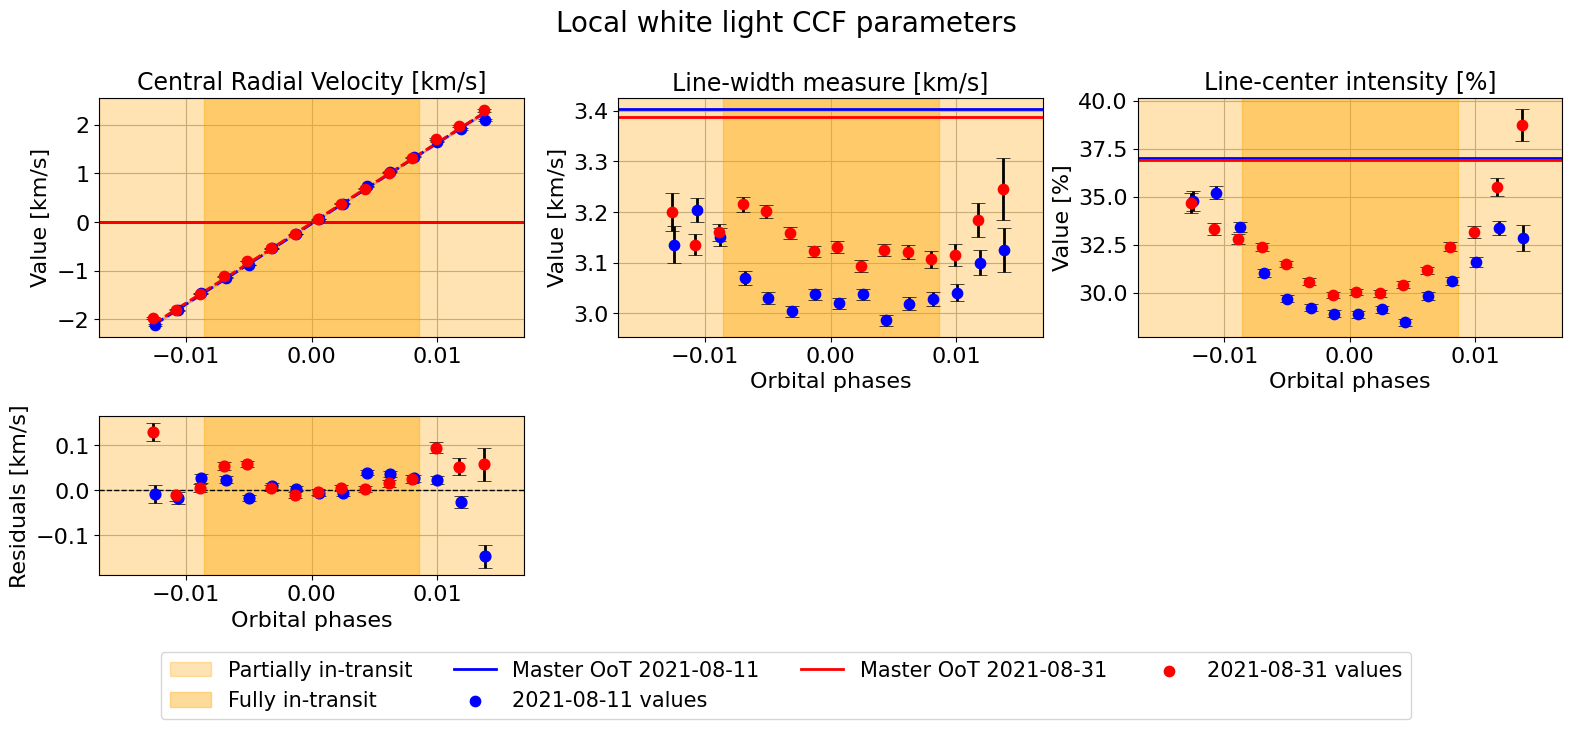

In [19]:
fit_results = mult_night.plot_parameters(param_type='phases', 
                                      fit_each=True, 
                                      fit_combined=False, 
                                      fit_param_indices = np.array([0]),
                                      suptitle="Local white light CCF parameters")

0it [00:00, ?it/s]

273it [00:00, 2724.16it/s, batch: 0 | bound: 0 | nc: 1 | ncall: 371 | eff(%): 31.343 | loglstar:   -inf < -6580.947 <    inf | logz: -6588.400 +/-  0.122 | dlogz: 7017.410 >  0.010]

547it [00:00, 2729.26it/s, batch: 0 | bound: 0 | nc: 7 | ncall: 1040 | eff(%): 35.519 | loglstar:   -inf < -209.034 <    inf | logz: -216.944 +/-  0.123 | dlogz: 155.407 >  0.010]  

820it [00:00, 2200.66it/s, batch: 0 | bound: 0 | nc: 6 | ncall: 2304 | eff(%): 29.244 | loglstar:   -inf < -115.335 <    inf | logz: -120.137 +/-  0.087 | dlogz: 55.299 >  0.010] 

1050it [00:00, 2092.54it/s, batch: 0 | bound: 0 | nc: 12 | ncall: 4001 | eff(%): 23.328 | loglstar:   -inf < -106.841 <    inf | logz: -111.704 +/-  0.087 | dlogz: 49.670 >  0.010]

...

17751it [00:25, 666.02it/s, batch: 6 | bound: 3 | nc: 23 | ncall: 374368 | eff(%):  4.600 | loglstar: -3.510 <  0.405 <  0.500 | logz: -14.957 +/-  0.112 | stop:  1.169]

17858it [00:26, 778.19it/s, batch: 6 | bound: 3 | nc: 1 | ncall: 375751 | eff(%):  4.612 | loglstar: -3.510 <  0.567 <  0.500 | logz: -14.957 +/-  0.112 | stop:  1.169] 

18309it [00:26, 1319.66it/s, batch: 6 | bound: 3 | nc: 1 | ncall: 376202 | eff(%):  4.729 | loglstar: -3.510 <  1.557 <  0.500 | logz: -14.957 +/-  0.112 | stop:  0.963]

18309it [00:26, 695.30it/s, batch: 6 | bound: 3 | nc: 1 | ncall: 376202 | eff(%):  4.729 | loglstar: -3.510 <  1.557 <  0.500 | logz: -14.957 +/-  0.112 | stop:  0.963] 

Positive vs Negative slope
logZ(m>0)  = -37.143 ± 0.105
logZ(m<0)  = -14.958 ± 0.105
log Bayes factor = 22.185
Negative slope favored.
Linear fit parameters:
m = -16.073581 +/- 1.219970
b = 41.434567 +/- 0.749941
ln_f = -4.406240 +/- 0.356293
------------------------------


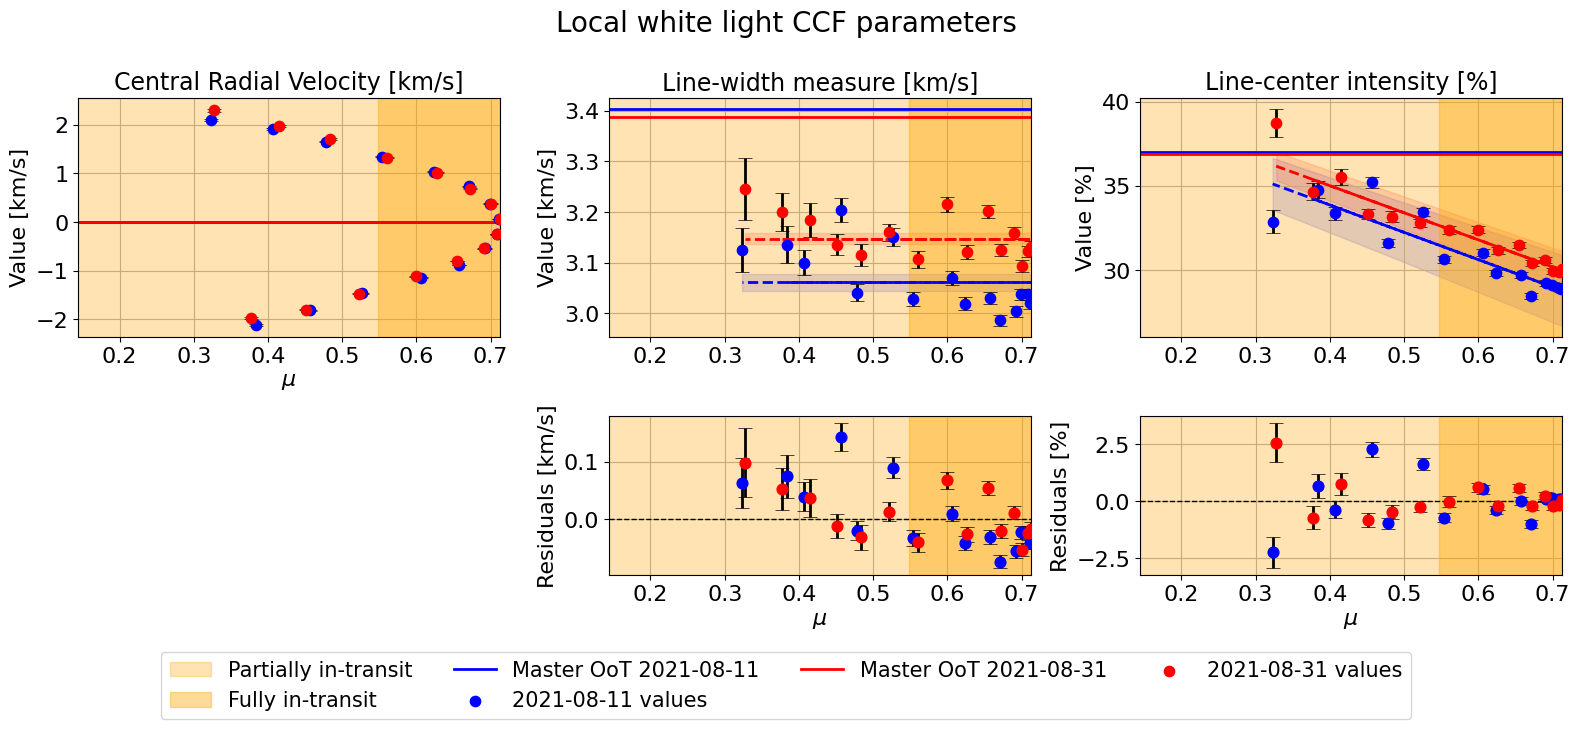

In [20]:
fit_results = mult_night.plot_parameters(param_type='mu', 
                                      fit_each=True, 
                                      fit_combined=False, 
                                      fit_param_indices = np.array([1, 2]),
                                      suptitle="Local white light CCF parameters")